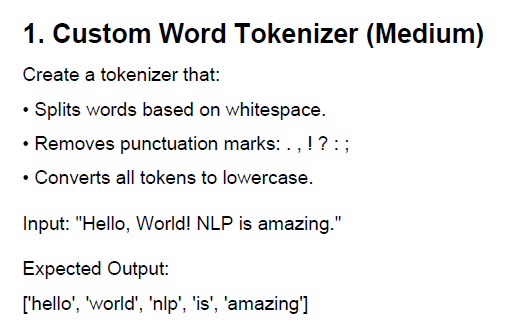

In [1]:
"Hello, World! NLP is amazing."

'Hello, World! NLP is amazing.'

In [2]:
import string

def custom_tokenizer(text):
    #Remove punctuation
    text = text.translate(str.maketrans('', '', '.,!?:;'))

    #lowercase
    text = text.lower()

    #Split by whitespace
    tokens = text.split()

    return tokens

text = "Hello, World! NLP is amazing."
print(custom_tokenizer(text))

['hello', 'world', 'nlp', 'is', 'amazing']


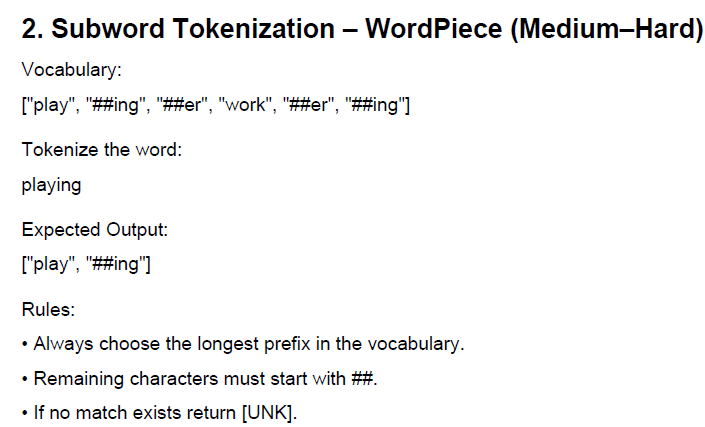

In [3]:
def wordpiece_tokenize(word, vocab):
    tokens = []
    i = 0

    while i < len(word):
        match = None

        for j in range(len(word), i, -1):
            sub = word[i:j]
            if i > 0:
                sub = "##" + sub

            if sub in vocab:
                match = sub
                break

        if match is None:
            return ["[UNK]"]

        tokens.append(match)
        i = j

    return tokens

vocab = ["play", "##ing", "##er", "work", "##er", "##ing"]
print(wordpiece_tokenize("playing", vocab))

['play', '##ing']


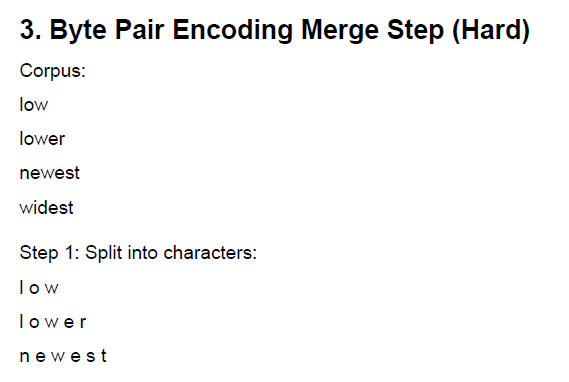   

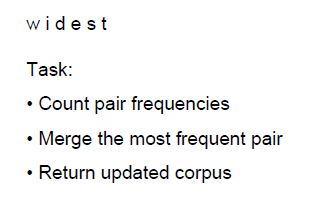

In [5]:
from collections import defaultdict

def get_pairs(word_list):
    pairs = defaultdict(int)

    for word in word_list:
        symbols = word.split()
        for i in range(len(symbols) - 1):
            pair = (symbols[i], symbols[i+1])
            pairs[pair] += 1

    return pairs
def merge_pair(pair, word_list):
    merged_word_list = []
    bigram = " ".join(pair)
    replacement = "".join(pair)

    for word in word_list:
        new_word = word.replace(bigram, replacement)
        merged_word_list.append(new_word)

    return merged_word_list

corpus = [
    "l o w",
    "l o w e r",
    "n e w e s t",
    "w i d e s t"
]

pairs = get_pairs(corpus)
best_pair = max(pairs, key=pairs.get)

updated_corpus = merge_pair(best_pair, corpus)

print("Most frequent pair:", best_pair)
print("Updated corpus:")
for word in updated_corpus:
    print(word)

Most frequent pair: ('l', 'o')
Updated corpus:
lo w
lo w e r
n e w e s t
w i d e s t


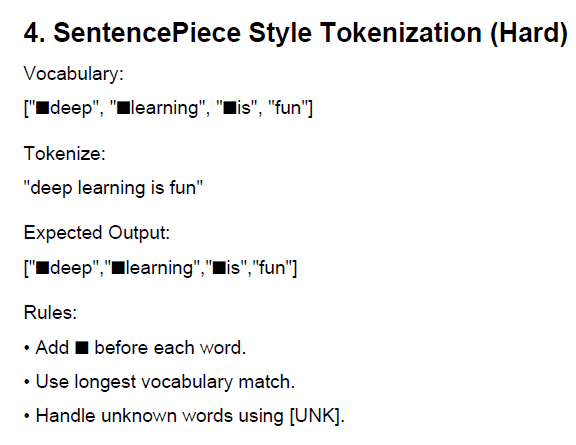

In [6]:
def sentencepiece_tokenize(text, vocab):
    words = text.split()
    tokens = []

    for word in words:
        word_with_marker = "■" + word

        if word_with_marker in vocab:
            tokens.append(word_with_marker)
        elif word in vocab:
            tokens.append(word)
        else:
            tokens.append("[UNK]")

    return tokens

vocab = ["■deep", "■learning", "■is", "fun"]
text = "deep learning is fun"

print(sentencepiece_tokenize(text, vocab))

['■deep', '■learning', '■is', 'fun']


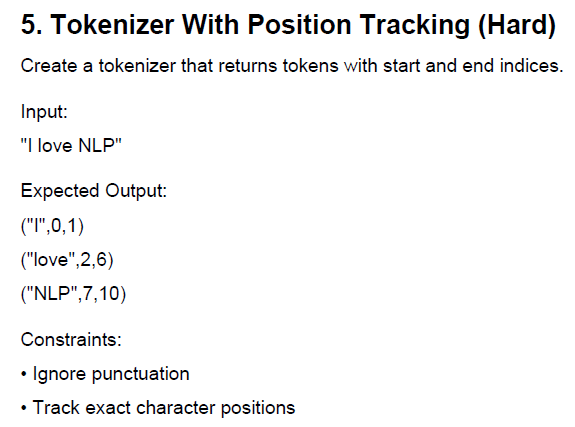

In [7]:
def tokenizer_with_positions(text):
    tokens = []
    start = 0

    for word in text.split():
        start = text.find(word, start)
        end = start + len(word)

        tokens.append((word, start, end))
        start = end

    return tokens

text = "I love NLP"
result = tokenizer_with_positions(text)

for token in result:
    print(token)

('I', 0, 1)
('love', 2, 6)
('NLP', 7, 10)


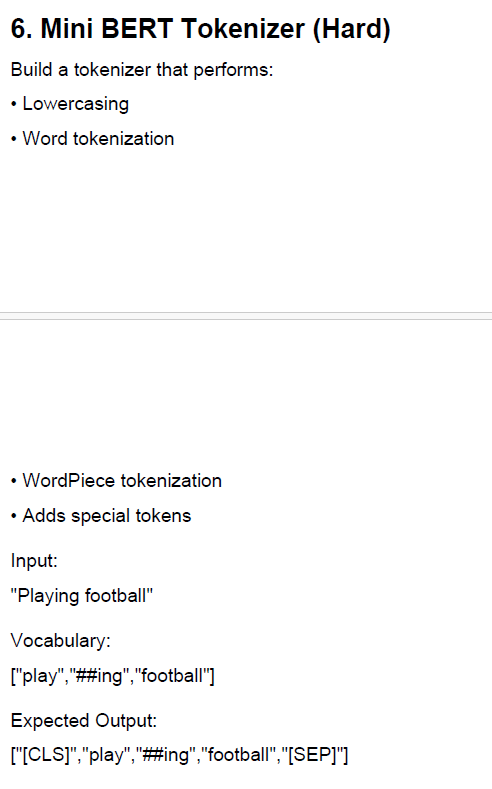

In [8]:
def mini_bert_tokenizer(text, vocab):
    #Lowercase
    text = text.lower()

    #Word tokenization
    words = text.split()

    def wordpiece(word):
        tokens = []
        i = 0

        while i < len(word):
            match = None

            for j in range(len(word), i, -1):
                sub = word[i:j]
                if i > 0:
                    sub = "##" + sub

                if sub in vocab:
                    match = sub
                    break

            if match is None:
                return ["[UNK]"]

            tokens.append(match)
            i = j

        return tokens

    final_tokens = ["[CLS]"]

    for word in words:
        final_tokens.extend(wordpiece(word))

    final_tokens.append("[SEP]")

    return final_tokens

vocab = ["play", "##ing", "football"]
text = "Playing football"

print(mini_bert_tokenizer(text, vocab))

['[CLS]', 'play', '##ing', 'football', '[SEP]']
